# 02 — Spiegazioni XAI: SHAP, DiCE, Anchors

Genera le spiegazioni locali per i pazienti selezionati.
Carica il modello e lo split da artifacts/ — non riallena niente.

Prerequisiti: aver eseguito src/prepare_data.py e src/train_model.py.
Prima di committare: Kernel → Restart & Clear Output.

## 0. Carico modello e split

In [ ]:
from pathlib import Path
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

model = joblib.load(ROOT / "artifacts" / "model.joblib")
split = joblib.load(ROOT / "artifacts" / "split.joblib")
X_train, X_test = split["X_train"], split["X_test"]
y_train, y_test = split["y_train"], split["y_test"]

pred  = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]

# Scelgo i due pazienti di riferimento: uno predetto malato, uno sano
# Questi stessi pazienti verranno usati per tutti e tre i metodi XAI
idx_malato = int(np.where(pred == 1)[0][0])
idx_sano   = int(np.where(pred == 0)[0][0])

print(f"Paziente MALATO  -> indice {idx_malato} | prob={proba[idx_malato]:.2f} | reale={y_test.iloc[idx_malato]}")
print(f"Paziente SANO    -> indice {idx_sano}   | prob={proba[idx_sano]:.2f} | reale={y_test.iloc[idx_sano]}")
print()
print("Feature del paziente MALATO:")
print(X_test.iloc[idx_malato].to_string())

Paziente MALATO  -> indice 2 | prob=0.85 | reale=1
Paziente SANO    -> indice 0   | prob=0.10 | reale=0

Feature del paziente MALATO:
age          59.0
sex           1.0
cp            0.0
trestbps    138.0
chol        271.0
fbs           0.0
restecg       0.0
thalach     182.0
exang         0.0
oldpeak       0.0
slope         2.0
ca            0.0
thal          2.0


## 1. SHAP — attribuzioni locali

Waterfall plot: mostra come ogni feature spinge la predizione
dal valore base E[f(x)] verso l'output finale f(x).

In [2]:
import shap

explainer = shap.TreeExplainer(model)
expl = explainer(X_test)[:, :, 1]   # classe 1 = malattia

print(f"Valore base SHAP (prob. media malattia): {expl.base_values[0]:.3f}")

Valore base SHAP (prob. media malattia): 0.547


=== SHAP — paziente predetto MALATO ===


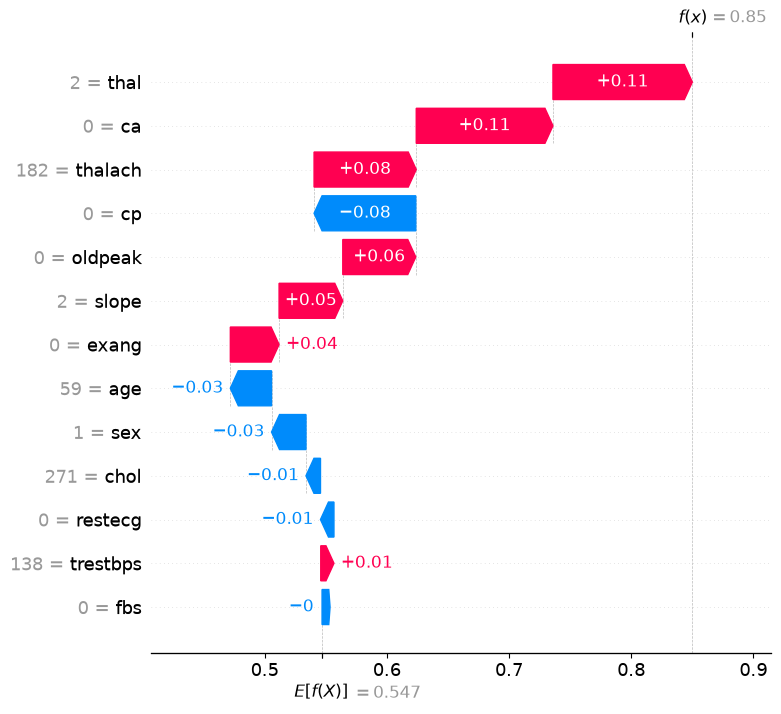

In [3]:
# Paziente MALATO
print("=== SHAP — paziente predetto MALATO ===")
shap.plots.waterfall(expl[idx_malato], max_display=13)

=== SHAP — paziente predetto SANO ===


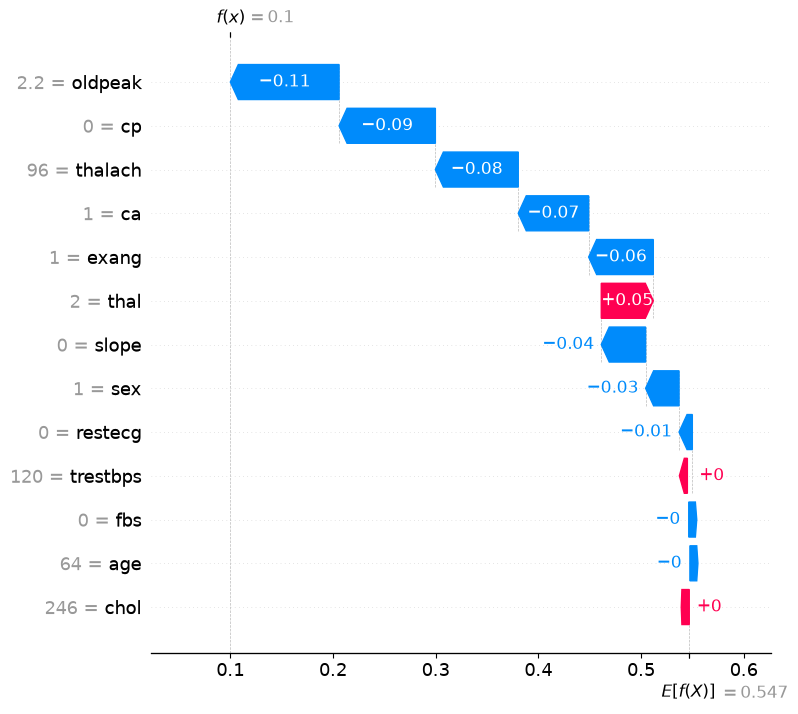

In [4]:
# Paziente SANO
print("=== SHAP — paziente predetto SANO ===")
shap.plots.waterfall(expl[idx_sano], max_display=13)

=== SHAP — Beeswarm plot (intero test set) ===


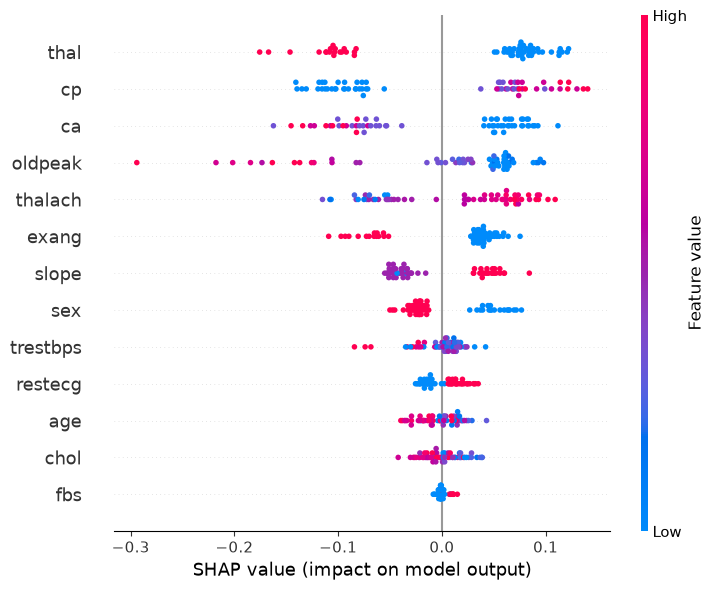

In [5]:
# Beeswarm plot — distribuzione dei valori SHAP su tutti i campioni del test set
print("=== SHAP — Beeswarm plot (intero test set) ===")
shap.plots.beeswarm(expl, max_display=13)

=== SHAP — Bar plot (intero test set) ===


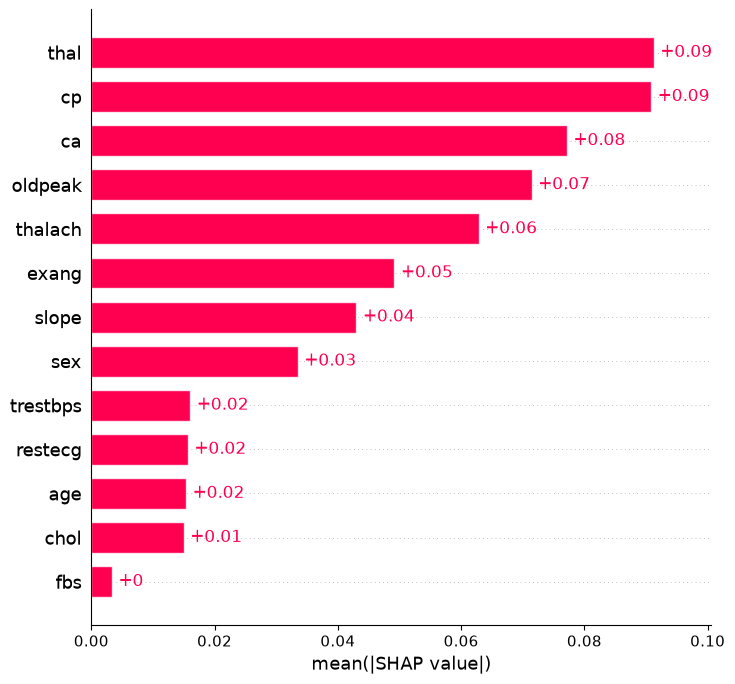

In [6]:
# Bar plot — importanza media assoluta delle feature su tutto il test set
print("=== SHAP — Bar plot (intero test set) ===")
shap.plots.bar(expl, max_display=13)

## 2. DiCE — spiegazioni controfattuali

Risponde a: "cosa dovrebbe cambiare perché il modello cambi idea?"
Le feature non modificabili (age, sex) sono escluse dai controfattuali
per garantire azionabilità clinica.

In [7]:
import dice_ml

cont_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
modifiable    = ["trestbps", "chol", "thalach", "oldpeak", "cp", "slope"]

# Fix compatibilità dice-ml / pandas: conversione colonna per colonna in float64
df_train = X_train.copy()
for col in df_train.columns:
    df_train[col] = df_train[col].astype("float64")
df_train["target"] = y_train.values.astype("float64")

d = dice_ml.Data(dataframe=df_train,
                 continuous_features=cont_features,
                 outcome_name="target")
m = dice_ml.Model(model=model, backend="sklearn")
# method="genetic": algoritmo evolutivo che ottimizza plausibilità e diversità
# dei controfattuali. Più lento di "random" ma produce risultati più realistici,
# adatti a essere mostrati a partecipanti non tecnici nello studio con gli utenti.
dice_exp = dice_ml.Dice(d, m, method="genetic")

In [8]:
# Paziente MALATO
query_malato = X_test.iloc[[idx_malato]].copy()
for col in query_malato.columns:
    query_malato[col] = query_malato[col].astype("float64")

cf_malato = dice_exp.generate_counterfactuals(
    query_malato,
    total_CFs=3,
    desired_class="opposite",
    features_to_vary=modifiable,
)
cf_malato.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:01<00:00,  1.20s/it]

Query instance (original outcome : 1)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,59.0,1.0,0.0,138.0,271.0,0.0,0.0,182.0,0.0,0.0,2.0,0.0,2.0,1



Diverse Counterfactual set (new outcome: 0)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,-,-,-,125.0,300.0,-,-,71.0,-,-,0.0,-,-,0.0
0,-,-,-,125.0,126.0,-,-,71.0,-,-,1.0,-,-,0.0
0,-,-,3.0,94.0,300.0,-,-,71.0,-,-,-,-,-,0.0


In [10]:
# Paziente SANO
query_sano = X_test.iloc[[idx_sano]].copy()
for col in query_sano.columns:
    query_sano[col] = query_sano[col].astype("float64")

cf_sano = dice_exp.generate_counterfactuals(
    query_sano,
    total_CFs=3,
    desired_class="opposite",
    features_to_vary=modifiable,
)
cf_sano.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:01<00:00,  1.02s/it]

Query instance (original outcome : 0)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,64.0,1.0,0.0,120.0,246.0,0.0,0.0,96.0,1.0,2.2,0.0,1.0,2.0,0



Diverse Counterfactual set (new outcome: 1)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,-,-,3.0,145.0,233.0,-,-,150.0,-,2.3,-,-,-,1.0
0,-,-,3.0,140.0,239.0,-,-,151.0,-,1.8,2.0,-,-,1.0
0,-,-,3.0,125.0,213.0,-,-,125.0,-,1.4,2.0,-,-,1.0


## 3. Anchors — regole locali SE-ALLORA

Risponde a: "quale condizione minima basta a fissare questa predizione?"
- Precision: proporzione di casi nel vicinato in cui la regola è corretta
- Coverage: proporzione di input a cui la regola si applica

In [11]:
from alibi.explainers import AnchorTabular

predict_fn = lambda x: model.predict(x)
anchor_exp = AnchorTabular(predict_fn, feature_names=list(X_train.columns))
anchor_exp.fit(X_train.values, disc_perc=(25, 50, 75))

AnchorTabular(meta={
  'name': 'AnchorTabular',
  'type': ['blackbox'],
  'explanations': ['local'],
  'params': {'seed': None, 'disc_perc': (25, 50, 75)}}
)

In [12]:
# Paziente MALATO
a = anchor_exp.explain(X_test.iloc[idx_malato].values, threshold=0.95)
classe = int(predict_fn(X_test.iloc[[idx_malato]].values)[0])
print("=== Anchors — paziente predetto MALATO ===")
print("SE   " + "  E  ".join(a.anchor) if a.anchor else "(nessuna regola trovata)")
print(f"ALLORA predizione = {classe}  (1=malato)")
print(f"Precision: {a.precision:.2f}  |  Coverage: {a.coverage:.2f}")

=== Anchors — paziente predetto MALATO ===
SE   thal <= 2.00  E  thalach > 165.00  E  ca <= 0.00
ALLORA predizione = 1  (1=malato)
Precision: 0.98  |  Coverage: 0.24


In [13]:
# Paziente SANO
a2 = anchor_exp.explain(X_test.iloc[idx_sano].values, threshold=0.95)
classe2 = int(predict_fn(X_test.iloc[[idx_sano]].values)[0])
print("=== Anchors — paziente predetto SANO ===")
print("SE   " + "  E  ".join(a2.anchor) if a2.anchor else "(nessuna regola trovata)")
print(f"ALLORA predizione = {classe2}  (0=sano)")
print(f"Precision: {a2.precision:.2f}  |  Coverage: {a2.coverage:.2f}")

=== Anchors — paziente predetto SANO ===
SE   oldpeak > 1.60  E  exang > 0.00  E  thalach <= 132.00  E  slope <= 1.00
ALLORA predizione = 0  (0=sano)
Precision: 1.00  |  Coverage: 0.26


---
## Glossario

### Feature del dataset (Cleveland Heart Disease)

| Sigla / termine | Significato in italiano |
|---|---|
| `age` | Età del paziente (anni) |
| `sex` | Sesso — 1 = maschio, 0 = femmina |
| `cp` | Tipo di dolore toracico (*chest pain type*) — 0 = asintomatico, 1 = angina atipica, 2 = dolore non anginoso, 3 = angina tipica |
| `trestbps` | Pressione arteriosa a riposo (*resting blood pressure*), in mmHg |
| `chol` | Colesterolo sierico (*serum cholesterol*), in mg/dl |
| `fbs` | Glicemia a digiuno > 120 mg/dl (*fasting blood sugar*) — 1 = sì, 0 = no |
| `restecg` | Risultati dell'ECG a riposo (*resting electrocardiographic results*) — 0 = normale, 1 = anomalia onda ST-T, 2 = ipertrofia ventricolare sinistra |
| `thalach` | Frequenza cardiaca massima raggiunta durante il test da sforzo (*maximum heart rate achieved*) |
| `exang` | Angina indotta dall'esercizio (*exercise-induced angina*) — 1 = sì, 0 = no |
| `oldpeak` | Depressione del tratto ST indotta dall'esercizio rispetto al riposo (in mm) |
| `slope` | Pendenza del segmento ST al picco dell'esercizio — 0 = discendente, 1 = piatta, 2 = ascendente |
| `ca` | Numero di vasi coronarici principali visibili alla fluoroscopia (0–3) |
| `thal` | Talassemia / perfusione miocardica — 1 = normale, 2 = difetto fisso, 3 = difetto reversibile |

